# Classification after Clustering with Agglomerative Clustering

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
pd.pandas.set_option('display.max_columns', None)

In [ ]:
# Create a DataFrame 
df = pd.read_csv(r"./data/clustered_data.csv")
# Print the shape of dataset
print(df.shape)

(2240, 22)


In [ ]:
df['cluster'].unique()

array([0, 1, 2])

### Split X and y 

In [ ]:
X = df.drop('cluster', axis = 1) #dropping the target column which is 'cluster'
y = df['cluster']

## Using  Randomized Search Cross Validation Method

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay,\
                            precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics 

In [ ]:
# these are the models for classification problems 
models = {"Random Forest": RandomForestClassifier(),
         "Decision Tree": DecisionTreeClassifier(),
         "Gradient Boosting": GradientBoostingClassifier(),
         "Logistic Regression": LogisticRegression(),
         "K-Neighbors Classifier": KNeighborsClassifier(),
         "XGBClassifier": XGBClassifier(), 
         "CatBoosting Classifier": CatBoostClassifier(verbose=False),
         "AdaBoost Classifier": AdaBoostClassifier()
}

- ### We will create a generic function to check each model's performance so that we can compare those

In [ ]:
# Create a function which evaluate models and return a report 

def evaluate_models(X, y, models):
    '''
    '''
    # Separate dataset into train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

    models_list = []
    scores = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train)

        # Make Prediction
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test, y_pred)

        model_name = list(models.keys())[i]
        print(f'---- score for ---- {model_name} ----')
        print(f'{score}')
        models_list.append(model_name)
        scores.append(score)
    print()

    report = pd.DataFrame()
    report['Model_name'] = models_list
    report['Score'] = scores
    return report 

## Let's Check the report 

In [ ]:
report = evaluate_models(X, y, models)

---- score for ---- Random Forest ----
0.96875
---- score for ---- Decision Tree ----
0.9441964285714286
---- score for ---- Gradient Boosting ----
0.9732142857142857
---- score for ---- Logistic Regression ----
0.8772321428571429
---- score for ---- K-Neighbors Classifier ----
0.8102678571428571
---- score for ---- XGBClassifier ----
0.96875
---- score for ---- CatBoosting Classifier ----
0.9754464285714286
---- score for ---- AdaBoost Classifier ----
0.9441964285714286



In [ ]:
report.sort_values('Score')

,Model_name,Score
4,K-Neighbors Classifier,0.810268
3,Logistic Regression,0.877232
1,Decision Tree,0.944196
7,AdaBoost Classifier,0.944196
0,Random Forest,0.968750
5,XGBClassifier,0.968750
2,Gradient Boosting,0.973214
6,CatBoosting Classifier,0.975446


## From the report above we can see the that the  CatBoostClassifier model performed the best, so we will train our model using `CatBoost Classifier`.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
994,72.0,2,0,1,2,64587.0,108.0,4428.0,49.0,66.0,0.0,16.0,0.0,6.0,20.0,1,1,4,2,0,3
2162,69.0,2,1,1,1,47320.0,414.0,4753.0,10.0,200.0,19.0,111.0,50.0,15.0,19.0,5,1,8,6,0,6
906,65.0,2,0,0,0,86429.0,1449.0,4641.0,10.0,464.0,28.0,556.0,29.0,18.0,37.0,7,4,7,0,1,2
572,48.0,1,0,1,1,38593.0,177.0,4710.0,42.0,51.0,12.0,49.0,17.0,24.0,24.0,4,1,3,3,0,8
1877,68.0,2,1,0,0,72905.0,1515.0,4580.0,52.0,407.0,81.0,445.0,120.5,81.0,126.5,3,7,9,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,57.0,2,1,1,2,44078.0,41.0,4431.0,17.0,24.0,1.0,10.0,2.0,0.0,4.0,2,0,3,2,0,5
1095,47.0,2,0,1,1,61825.0,424.0,4747.0,56.0,162.0,50.0,100.0,55.0,30.0,27.0,4,2,8,1,0,4
1130,75.0,3,1,1,1,67381.0,957.0,4951.0,67.0,815.0,8.0,53.0,11.0,0.0,70.0,2,2,9,4,1,7
1294,63.0,4,0,1,2,48918.0,62.0,4499.0,21.0,52.0,0.0,9.0,0.0,0.0,1.0,1,0,4,2,0,4


### Let's do HyperParameter Tuning Using `RandomizedSearchCV`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

param_dist = {
    "iterations": [200, 500, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7],
    "border_count": [32, 64, 128]
}

random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=30,          # Try 30 random combinations
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)



random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print()
print("Best CV Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 1000, 'depth': 4, 'border_count': 64}

Best CV Score: 0.9719399279623939


### So we got our best parameters. Let's now train the model with those parameters.

In [ ]:
best_model = random_search.best_estimator_

**Initialize model with best parameters**

In [ ]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)


print('CatBoost Classifier ')
print ("Accuracy Score value: {:.4f}".format(score))
print(cr)

CatBoost Classifier 
Accuracy Score value: 0.9777
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       179
           1       1.00      0.97      0.98       259
           2       0.95      0.99      0.97       234

    accuracy                           0.98       672
   macro avg       0.98      0.98      0.98       672
weighted avg       0.98      0.98      0.98       672



## Confusion Matrix of the model.

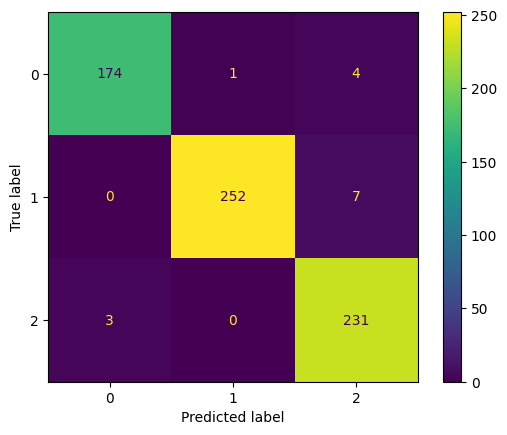

[CV] END border_count=64, depth=4, iterations=1000, l2_leaf_reg=5, learning_rate=0.05; total time=   1.1s
[CV] END border_count=64, depth=10, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   4.1s
[CV] END border_count=128, depth=8, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=   5.2s
[CV] END border_count=32, depth=4, iterations=500, l2_leaf_reg=7, learning_rate=0.03; total time=   0.7s
[CV] END border_count=64, depth=10, iterations=1000, l2_leaf_reg=7, learning_rate=0.01; total time=  27.0s
[CV] END border_count=64, depth=10, iterations=500, l2_leaf_reg=3, learning_rate=0.01; total time=  19.5s
[CV] END border_count=64, depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.03; total time=   2.6s
[CV] END border_count=64, depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.03; total time=   2.2s
[CV] END border_count=128, depth=8, iterations=1000, l2_leaf_reg=7, learning_rate=0.01; total time=  15.9s
[CV] END border_count=32, depth=6, iterations=1

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)



**We can see, that the model performed pretty well.**

- Class 0: 174 correct, only 5 misclassified.
- Class 1: 252 correct, only 7 misclassified.
- Class 2: 231 correct, only 3 misclassified.

In [ ]:
import pickle
with open('models/catboostclf.pkl', 'wb') as f:
    pickle.dump(best_model, f)